# Análise dos Resultados

Requer `previsoes_consolidadas.csv` gerado por `02_modelos.R` (M0, M1, M2, painel alinhado).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from arch.bootstrap import MCS
from datetime import datetime

CAMINHO = "./data/"


In [25]:
# ── Carrega dados ────────────────────────────────────────────────
df_acoes        = pd.read_csv(CAMINHO + "acoes_elegiveis.csv")
df_trends       = pd.read_csv(CAMINHO + "google_trends_svi.csv",     parse_dates=["semana"])
df_final        = pd.read_csv(CAMINHO + "base_final_tcc.csv",        parse_dates=["semana"])

df_previsoes    = pd.read_csv(CAMINHO + "previsoes_consolidadas.csv", parse_dates=["semana"])
df_resumo_params = pd.read_csv(CAMINHO + "resumo_parametros.csv").set_index("ticker_b3")

# ── Proporção de zeros no SVI ─────────────────────────────────────
zeros_pct = df_trends.groupby("ticker_b3")["svi"].apply(lambda x: (x == 0).mean())
df_resumo_params["svi_zeros_pct"] = zeros_pct.reindex(df_resumo_params.index)
tickers_erro_m2 = df_previsoes[df_previsoes["rv_pred_m2"].isna()]["ticker_b3"].unique()

In [23]:
df_previsoes[df_previsoes["rv_pred_m2"].isna()]["ticker_b3"].unique()

<StringArray>
['AZEV3', 'BEES3', 'MRSA3B', 'SCAR3']
Length: 4, dtype: str

In [24]:
df_previsoes[df_previsoes["status_m2"] != "ok"]["ticker_b3"].unique()

<StringArray>
[ 'AALR3',  'AFLT3',  'AMER3',  'AXIA3',  'AXIA6',  'AZEV3',  'AZZA3',
  'BALM4',  'BAZA3',  'BDLL4',  'BEES3',  'BMEB3',  'BMEB4',  'BPAC5',
  'BRSR5',  'CBEE3',  'CEDO3',  'CVCB3',  'DEXP4',  'DOHL4',  'EALT3',
  'EMAE4', 'EQMA3B',  'FHER3',  'GSHP3',  'HBTS5',  'ISAE3',  'ISAE4',
  'LUXM4',  'MBRF3',  'MNDL3', 'MRSA3B',  'PATI4',  'PEAB3',  'PLAS3',
 'PPLA11',  'PTNT4',  'RNEW3',  'RPAD3',  'RPAD5',  'SCAR3',  'TASA3',
  'TECN3',  'TKNO4',  'TPIS3',  'WHRL3']
Length: 46, dtype: str

# Testes qlike e MCS

In [26]:
# ── QLIKE loss ───────────────────────────────────────────────────
def qlike(rv, pred):
    """QLIKE: rv/pred - log(rv/pred) - 1. NaN onde rv ou pred <= 0."""
    ok = (rv > 0) & (pred > 0)
    r  = np.where(ok, rv / pred, np.nan)
    return np.where(ok, r - np.log(r) - 1, np.nan)

NOMES_MODELOS = {
    "qlike_m0": "M0_RW",
    "qlike_m1": "M1_GARCH",
    "qlike_m2": "M2_GARCHX",
}

def filtrar_tickers(df, zeros_pct, threshold_zeros=None, remove_singular=True):
    """Filtra tickers por % de zeros no SVI e/ou erros de convergencia no M2.
    Retorna (df_filtrado, info_dict com contagens para relatorio)."""
    tickers_erro = set(df.loc[df["rv_pred_m2"].isna(), "ticker_b3"].unique())
    info = {"n_total": df["ticker_b3"].nunique(), "n_erros": len(tickers_erro)}

    if threshold_zeros is not None:
        ok = zeros_pct[zeros_pct < threshold_zeros].index
        df = df[df["ticker_b3"].isin(ok)]
        info["n_apos_zeros"]    = df["ticker_b3"].nunique()
        info["erros_apos_zeros"] = df[df["rv_pred_m2"].isna()]["ticker_b3"].nunique()

    if remove_singular:
        df = df[~df["ticker_b3"].isin(tickers_erro)]

    info["n_final"] = df["ticker_b3"].nunique()
    return df, info


def calcular_losses(df):
    """Calcula QLIKE por modelo. Retorna (losses sem NaN, n_descartadas)."""
    df = df.copy()
    for m in ["m0", "m1", "m2"]:
        df[f"qlike_{m}"] = qlike(df["rv"].values, df[f"rv_pred_{m}"].values)

    losses = (
        df[list(NOMES_MODELOS)]
        .dropna()
        .rename(columns=NOMES_MODELOS)
        .reset_index(drop=True)
    )
    return losses, len(df) - len(losses)


def rodar_mcs(losses, alpha=0.10):
    """Model Confidence Set. Retorna (mcs_obj, df_pvalores)."""
    mcs = MCS(losses, size=alpha, block_size=5, reps=1000, seed=42)
    mcs.compute()
    df_p = (
        mcs.pvalues
        .rename(columns={"Pvalue": "p_valor"})
        .assign(no_conjunto=lambda d: d["p_valor"] >= alpha)
        .sort_values("p_valor", ascending=False)
    )
    return mcs, df_p


def resumo_gamma(df_resumo, tickers):
    """Conta tickers com gamma significativo em >=50% das janelas."""
    df    = df_resumo.loc[df_resumo.index.isin(tickers)]
    n_sig = int((df["pct_signif_5pct"] >= 50).sum())
    top5  = df["pct_signif_5pct"].sort_values(ascending=False).head(5)
    return n_sig, top5


def gerar_bloco(df_prev, df_resumo, zeros_pct,
                threshold_zeros=None, remove_singular=True, label=""):
    """Gera bloco de texto com diagnostico para um cenario de filtragem."""
    df, info       = filtrar_tickers(df_prev, zeros_pct, threshold_zeros, remove_singular)
    tickers_finais = set(df["ticker_b3"].unique())
    losses, n_desc = calcular_losses(df)
    mcs, df_pval   = rodar_mcs(losses)
    n_sig, top5    = resumo_gamma(df_resumo, tickers_finais)

    # Formata texto
    sep = "═" * 60
    L   = [f"\n{sep}", f"  {label}", sep]

    L.append(f"  Tickers em df_previsoes              : {info['n_total']}")
    L.append(f"  Com erro (M2)                        : {info['n_erros']}")
    if threshold_zeros is not None:
        pct = int(threshold_zeros * 100)
        L.append(f"  Apos filtro zeros >={pct}%              : {info['n_apos_zeros']}  ({info['erros_apos_zeros']} com erro)")
    L.append(f"  Na comparacao final                  : {info['n_final']}")
    L.append(f"  Obs. OOS usadas / descartadas        : {len(losses)} / {n_desc}")

    L.append("\n  QLIKE medio:")
    for col in losses.columns:
        L.append(f"    {col:<15}: {losses[col].mean():.6f}")

    L.append("\n  MCS (alpha=10%):")
    for line in df_pval.to_string().split("\n"):
        L.append(f"    {line}")
    L.append(f"\n  Conjunto de confianca : {list(mcs.included)}")
    L.append(f"  Excluidos             : {list(mcs.excluded)}")

    L.append(f"\n  gamma significativo em >=50% das janelas:")
    L.append(f"    {n_sig}/{info['n_final']} tickers")
    L.append("\n  Top 5 por % de janelas significativas (gamma):")
    L.append(top5.to_string())

    return "\n".join(L) + "\n"

In [27]:
# ── Gera diagnostico ─────────────────────────────────────────────
cenarios = [
    # (threshold, remove_singular_matrix, label)
    (None, False, "1. Considerando todos os ativo"),
    (0.70, True,  "2. Filtro >=70% e erros na previsão do M2"),
    (0.50, True,  "3. Filtro >=50% e erros na previsão do M2"),
]

TXT = "/diagnostico_filtros.txt"
with open(f"{CAMINHO}{TXT}", "w", encoding="utf-8") as f:
    f.write("Diagnostico - comparacao de cenarios\n")
    f.write(f"Gerado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

    for threshold, remove_sing, label in cenarios:
        bloco = gerar_bloco(df_previsoes, df_resumo_params, zeros_pct,
                            threshold, remove_sing, label)
        f.write(bloco)

print(f"✓ Salvo em {TXT}")

✓ Salvo em /diagnostico_filtros.txt


In [28]:
# ── Salvar QLIKE por ticker e MCS (todos os ativos) ──────────────
# Filtra apenas tickers com erro de singular matrix no M2
df_ok, info = filtrar_tickers(df_previsoes, zeros_pct,
                              threshold_zeros=None, remove_singular=False)

# Calcula QLIKE por observacao
df_ok = df_ok.copy()
for m in ["m0", "m1", "m2"]:
    df_ok[f"qlike_{m}"] = qlike(df_ok["rv"].values, df_ok[f"rv_pred_{m}"].values)

# QLIKE medio por ticker
df_qlike = (
    df_ok.groupby("ticker_b3")[list(NOMES_MODELOS)]
    .mean()
    .rename(columns=NOMES_MODELOS)
)

# MCS no agregado (pooled)
losses, n_desc = calcular_losses(df_ok)
mcs, df_mcs_principal = rodar_mcs(losses, alpha=0.10)

# Salva CSVs
df_qlike.to_csv(CAMINHO + "qlike_por_ticker.csv")
df_mcs_principal.to_csv(CAMINHO + "mcs_resultado.csv")

## Diagnósticos dos Resíduos Padronizados

Resultados de Ljung-Box em $z_t$ e $z_t^2$, Jarque-Bera e Q-Q plot para o
Top 5 de tickers ranqueados por `pct_signif_5pct` (significância de γ no M2).

In [29]:
df_diag = pd.read_csv(CAMINHO + "diagnosticos_residuos.csv")
df_z    = pd.read_csv(CAMINHO + "residuos_padronizados.csv")

tab = (
    df_diag
    .assign(ticker_b3=lambda d: pd.Categorical(d["ticker_b3"], ordered=True))
    .sort_values(["ticker_b3", "modelo"])
    [["ticker_b3", "modelo", "assimetria", "curtose",
      "lb_z_pvalor", "lb_z2_pvalor", "jb_pvalor"]]
    .round(4)
)
print(tab.to_string(index=False))

ticker_b3 modelo  assimetria  curtose  lb_z_pvalor  lb_z2_pvalor  jb_pvalor
    AALR3     m1     -1.5174   9.6140       0.4432        0.9067     0.0000
    AALR3     m2     -1.5179   9.6164       0.4431        0.9068     0.0000
    ABCB4     m1      0.5661   3.4237       0.8484        0.9587     0.0087
    ABCB4     m2      0.5662   3.4239       0.8484        0.9587     0.0086
    ABEV3     m1      0.4301   4.9365       0.5235        0.4634     0.0000
    ABEV3     m2      0.4313   4.9372       0.5241        0.4607     0.0000
    AERI3     m1      1.0538   9.0217       0.8281        0.9970     0.0000
    AERI3     m2      1.0538   9.0217       0.8281        0.9970     0.0000
    AFLT3     m1      0.0197   5.2700       0.1236        0.9357     0.0000
    AFLT3     m2      0.0200   5.2701       0.1237        0.9355     0.0000
    AGRO3     m1      0.1633   3.3075       0.1583        0.2028     0.5200
    AGRO3     m2      0.1633   3.3075       0.1583        0.2028     0.5200
    AHEB3   

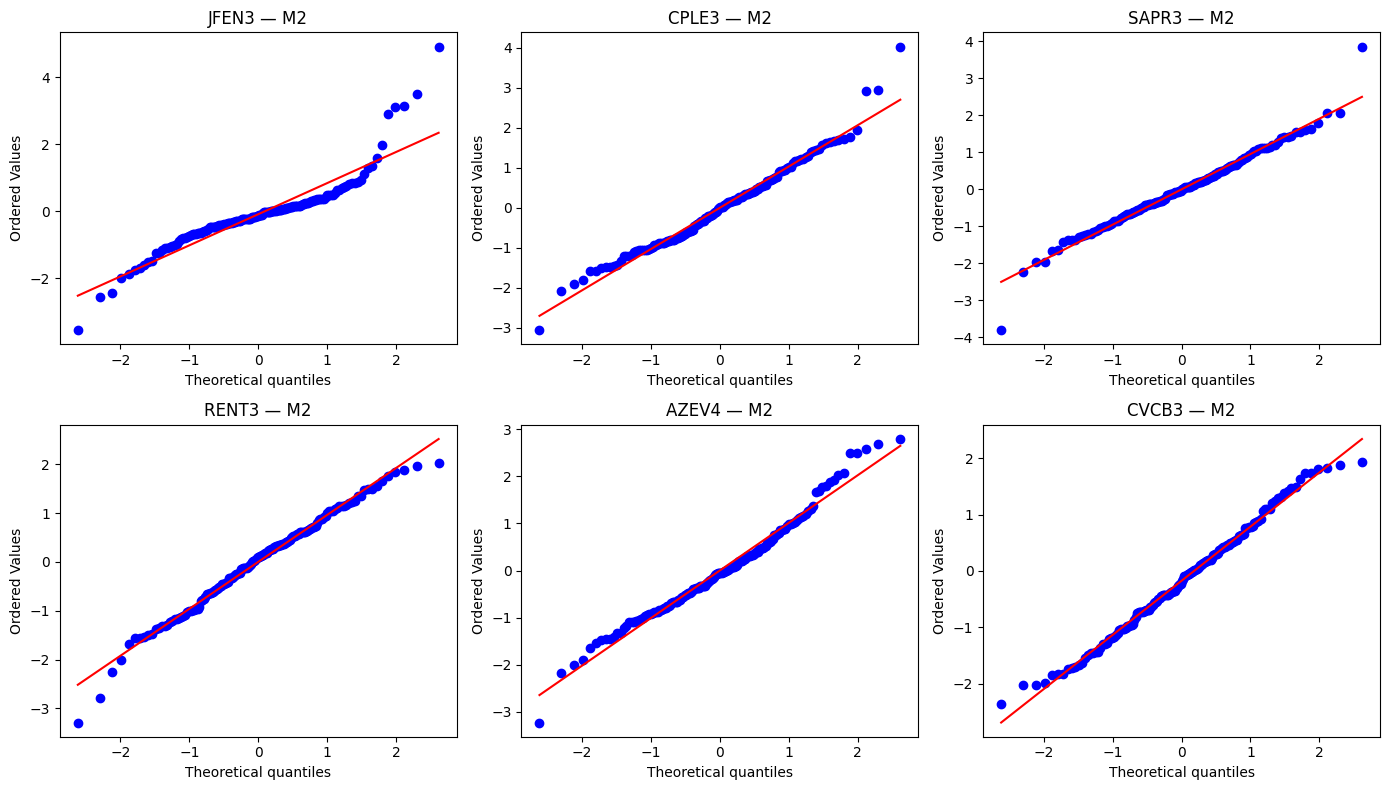

In [30]:
top_tickers = ["JFEN3","CPLE3","SAPR3","RENT3","AZEV4","CVCB3"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, tk in zip(axes.flat, top_tickers):
    z = df_z.query("ticker_b3 == @tk and modelo == 'm2'")["z"].values
    stats.probplot(z, dist="norm", plot=ax)
    ax.set_title(f"{tk} — M2")
plt.tight_layout()
plt.show()

# Outras coisas

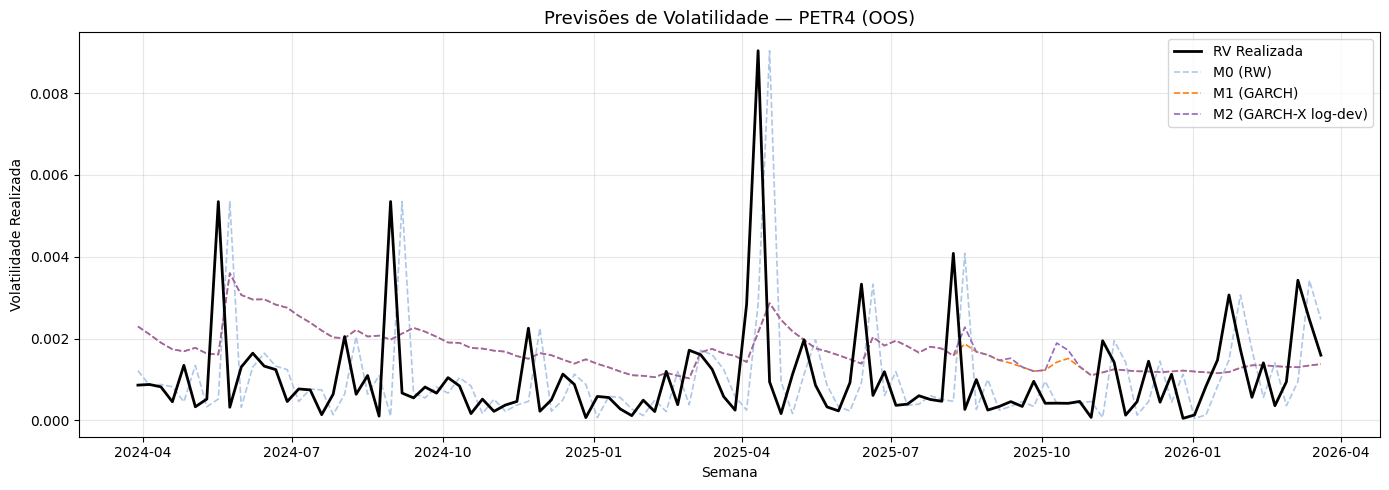

In [27]:
# ── Gráfico comparando as previsões ────────────────────────────────────────────────
TICKER = "PETR4" 

df_graf = (
    df_previsoes
    .query("ticker_b3 == @TICKER")
    .sort_values("semana")
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_graf["semana"], df_graf["rv"],         label="RV Realizada", color="black",   linewidth=2.0, zorder=5)
ax.plot(df_graf["semana"], df_graf["rv_pred_m0"], label="M0 (RW)",      color="#aec7e8", linewidth=1.2, linestyle="--")
ax.plot(df_graf["semana"], df_graf["rv_pred_m1"], label="M1 (GARCH)",   color="#ff7f0e", linewidth=1.2, linestyle="--")
ax.plot(df_graf["semana"], df_graf["rv_pred_m2"], label="M2 (GARCH-X log-dev)", color="#9467bd", linewidth=1.2, linestyle="--")

ax.set_title(f"Previsões de Volatilidade — {TICKER} (OOS)", fontsize=13)
ax.set_xlabel("Semana")
ax.set_ylabel("Volatilidade Realizada")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_qlike = pd.read_csv(CAMINHO + "qlike_por_ticker.csv")

df_qlike["melhor"] = df_qlike[list(NOMES_MODELOS.values())].idxmin(axis=1)
print(df_qlike["melhor"].value_counts())

melhor
M1_GARCH     160
M2_GARCHX    129
M0_RW          2
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


In [ ]:
float_cols = df_resumo_params.select_dtypes(include="float").columns
df_resumo_params[float_cols] = df_resumo_params[float_cols].round(4)
df_resumo_params.to_csv(CAMINHO + "apendice_resumo_params.csv")

df_resumo_params

,n_previsoes,gamma_medio,gamma_pval_medio,pct_signif_5pct,persistencia_m1,persistencia_m2,svi_zeros_pct
ticker_b3,,,,,,,
AALR3,103,0.2389,0.9029,9.7087,0.9814,1.0331,0.6552
ABCB4,103,0.0099,0.9524,3.8835,0.9909,0.9909,0.0000
ABEV3,103,0.1110,0.8162,17.4757,0.9394,0.9316,0.0000
AERI3,103,0.9962,0.6329,35.9223,0.9541,0.9273,0.0153
AFLT3,103,0.0000,1.0000,0.0000,0.9756,0.9885,0.9847
...,...,...,...,...,...,...,...
WHRL3,103,0.0000,1.0000,0.0000,0.9957,0.9966,0.9808
WHRL4,103,0.0780,0.6336,30.0971,0.9564,0.9739,0.8467
WIZC3,103,0.0030,0.9903,0.9709,0.9945,0.9944,0.3716


In [7]:
TICKERS = ["PINE4", "DASA3", "CPLE3", "SAPR11", "PETR4"]
df_resumo_params.query("ticker_b3 in @TICKERS")

,n_previsoes,gamma_medio,gamma_pval_medio,pct_signif_5pct,persistencia_m1,persistencia_m2,svi_zeros_pct
ticker_b3,,,,,,,
CPLE3,104,6.246337,0.210262,78.846154,0.695849,0.600778,0.011194
DASA3,104,3.037576,0.774140,20.192308,0.886827,0.881801,0.134328
PETR4,104,1.038957,0.951925,4.807692,0.931464,0.903026,0.000000
PINE4,104,3.182313,0.596163,40.384615,0.897563,0.856825,0.059701
SAPR11,104,7.794071,0.382825,32.692308,0.745125,0.464226,0.000000


In [35]:
TICKER = "PETR4"
df_previsoes.query("ticker_b3 == @TICKER").sort_values("semana")

,ticker_b3,semana,rv,rv_pred_m0,rv_pred_m1,omega,alpha,beta,status_m1,rv_pred_m2,alpha_m2,beta_m2,gamma,gamma_pval,status_m2,iguais
21528,PETR4,2024-03-29,0.000860,0.001214,0.002295,2.094128,1.208798e-01,0.799401,ok,0.002295,1.208954e-01,0.799394,4.477743e-08,1.0,ok,True
21529,PETR4,2024-04-05,0.000876,0.000860,0.002104,2.055251,1.162281e-01,0.804323,ok,0.002104,1.162362e-01,0.804338,1.719559e-08,1.0,ok,True
21530,PETR4,2024-04-12,0.000819,0.000876,0.001899,2.010878,1.136922e-01,0.807477,ok,0.001899,1.137173e-01,0.807475,1.662618e-08,1.0,ok,True
21531,PETR4,2024-04-19,0.000453,0.000819,0.001737,1.978373,1.126998e-01,0.808689,ok,0.001737,1.127042e-01,0.808687,3.598974e-08,1.0,ok,True
21532,PETR4,2024-04-26,0.001344,0.000453,0.001687,1.967881,1.130488e-01,0.808303,ok,0.001687,1.130586e-01,0.808296,1.160601e-08,1.0,ok,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21627,PETR4,2026-02-20,0.000357,0.001405,0.001324,0.008946,2.127453e-08,0.998996,ok,0.001323,8.539156e-10,0.999646,1.005504e-08,1.0,ok,False
21628,PETR4,2026-02-27,0.000943,0.000357,0.001309,0.007944,3.197209e-11,0.998999,ok,0.001308,2.227472e-09,0.999579,1.005043e-08,1.0,ok,False
21629,PETR4,2026-03-06,0.003425,0.000943,0.001298,0.006892,1.177949e-09,0.998999,ok,0.001297,3.435190e-10,0.999504,1.004775e-08,1.0,ok,False
21630,PETR4,2026-03-13,0.002470,0.003425,0.001342,0.009048,2.205073e-08,0.998989,ok,0.001341,1.544196e-09,0.999625,1.008217e-08,1.0,ok,False


In [34]:
df_previsoes["iguais"] = round(df_previsoes["rv_pred_m1"], 6) == round(df_previsoes["rv_pred_m2"], 6)
df_previsoes[df_previsoes["iguais"] == True]

,ticker_b3,semana,rv,rv_pred_m0,rv_pred_m1,omega,alpha,beta,status_m1,rv_pred_m2,alpha_m2,beta_m2,gamma,gamma_pval,status_m2,iguais
91,AALR3,2025-12-26,0.022151,0.001387,0.013979,6.265497e-01,4.412252e-10,0.996071,ok,0.013979,8.249660e-10,0.996060,1.006216e-08,1.0,ok,True
100,AALR3,2026-02-27,0.026478,0.000149,0.013392,1.079884e+01,3.731277e-11,0.919365,ok,0.013392,1.029658e-11,0.919296,1.226504e-08,1.0,ok,True
109,ABCB4,2024-05-03,0.000939,0.000727,0.001326,7.767481e-07,5.791844e-10,0.998998,ok,0.001326,1.275597e-08,0.998999,9.883887e-09,1.0,ok,True
110,ABCB4,2024-05-10,0.001079,0.000939,0.001302,1.047704e-06,2.313815e-09,0.998870,ok,0.001302,1.620994e-09,0.998870,9.824438e-09,1.0,ok,True
112,ABCB4,2024-05-24,0.001055,0.000611,0.001286,9.016866e-07,1.294599e-10,0.998919,ok,0.001286,2.148827e-10,0.998919,9.758767e-09,1.0,ok,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31403,YDUQ3,2026-02-20,0.000838,0.001959,0.003836,3.336302e-05,3.943395e-09,0.998694,ok,0.003836,6.675414e-10,0.998694,9.979501e-09,1.0,ok,True
31404,YDUQ3,2026-02-27,0.005215,0.000838,0.003795,2.188231e-05,1.985806e-12,0.998659,ok,0.003795,4.863179e-09,0.998659,9.981122e-09,1.0,ok,True
31405,YDUQ3,2026-03-06,0.006552,0.005215,0.003766,1.078232e-05,3.002210e-09,0.998761,ok,0.003766,6.531796e-10,0.998761,9.993149e-09,1.0,ok,True
31406,YDUQ3,2026-03-13,0.026762,0.006552,0.003934,9.915289e-02,2.321129e-09,0.996642,ok,0.003934,1.418866e-08,0.996649,9.986027e-09,1.0,ok,True


In [18]:
temp = df_previsoes.pivot_table(index="ticker_b3", columns="status_m2",values="semana", aggfunc="count").fillna(0).astype(int)

print(len(temp))
len(temp.query("ok != 103")) + len(temp.query("ok == 103"))

302


302